In [2]:
# AI-Based Early Disease Prediction with XAI
# Environment Setup

!pip install -q \
    pandas \
    numpy \
    scikit-learn \
    matplotlib \
    seaborn \
    plotly \
    xgboost \
    shap \
    lime \
    imbalanced-learn \
    joblib \
    ucimlrepo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# Check installed libraries

import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns
import plotly
import xgboost
import shap
import lime
import imblearn
import joblib

print("All required libraries imported successfully!")

print("\nLibrary Versions:")
print("Pandas       :", pd.__version__)
print("NumPy        :", np.__version__)
print("Scikit-learn :", sklearn.__version__)
print("XGBoost      :", xgboost.__version__)
print("SHAP         :", shap.__version__)

All required libraries imported successfully!

Library Versions:
Pandas       : 2.2.3
NumPy        : 2.1.3
Scikit-learn : 1.6.1
XGBoost      : 3.4.1
SHAP         : 0.52.0


In [4]:
# Step 2: Load Heart Disease Dataset

from ucimlrepo import fetch_ucirepo

# Fetch UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Separate features and target
X = heart_disease.data.features
y = heart_disease.data.targets

print("Dataset loaded successfully!")

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

print("\nFirst 5 rows:")
display(X.head())

print("\nTarget values:")
display(y.head())

Dataset loaded successfully!

Features shape: (303, 13)
Target shape: (303, 1)

Feature names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



Target values:


,num
0,0
1,2
2,1
3,0
4,0


In [5]:
# Step 3: Dataset Inspection

# Combine features and target for inspection
df = X.copy()
df["target"] = y["num"]

print("Dataset Shape:")
print(df.shape)

print("\n-----------------------------------")
print("COLUMN DATA TYPES")
print("-----------------------------------")
print(df.dtypes)

print("\n-----------------------------------")
print("MISSING VALUES")
print("-----------------------------------")
print(df.isnull().sum())

print("\n-----------------------------------")
print("DUPLICATE ROWS")
print("-----------------------------------")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n-----------------------------------")
print("ORIGINAL TARGET DISTRIBUTION")
print("-----------------------------------")
print(df["target"].value_counts().sort_index())

print("\n-----------------------------------")
print("STATISTICAL SUMMARY")
print("-----------------------------------")
display(df.describe().T)

Dataset Shape:
(303, 14)

-----------------------------------
COLUMN DATA TYPES
-----------------------------------
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

-----------------------------------
MISSING VALUES
-----------------------------------
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

-----------------------------------
DUPLICATE ROWS
-----------------------------------
Number of duplicate rows: 0

-----------------------------------
ORIGINAL TARGET DISTRIBUTION
-----------------------------------
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [6]:
# Step 4: Create Binary Target

# 0 = No heart disease
# 1, 2, 3, 4 = Heart disease present

df["target_binary"] = (df["target"] > 0).astype(int)

print("Binary target created successfully!")

print("\nBinary Target Distribution:")
print(df["target_binary"].value_counts().sort_index())

print("\nPercentage Distribution:")
print(
    (df["target_binary"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

print("\nTarget Mapping:")
print("0 → No Heart Disease")
print("1 → Heart Disease Present")

Binary target created successfully!

Binary Target Distribution:
target_binary
0    164
1    139
Name: count, dtype: int64

Percentage Distribution:
target_binary
0    54.13
1    45.87
Name: proportion, dtype: float64

Target Mapping:
0 → No Heart Disease
1 → Heart Disease Present


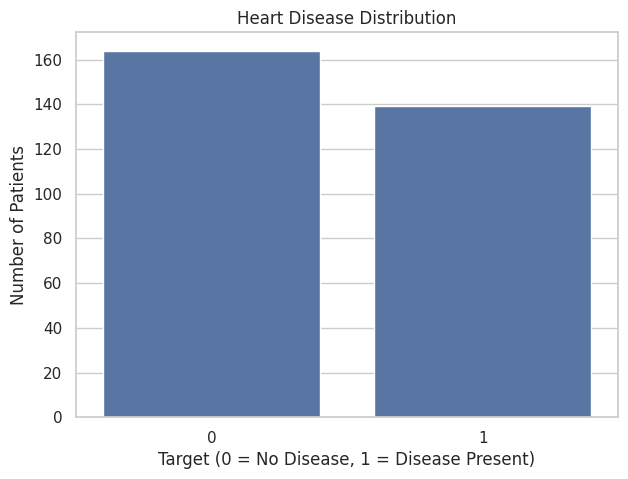

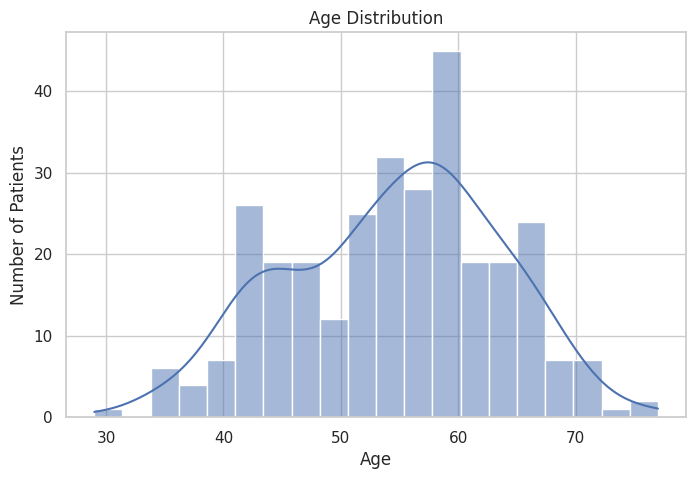

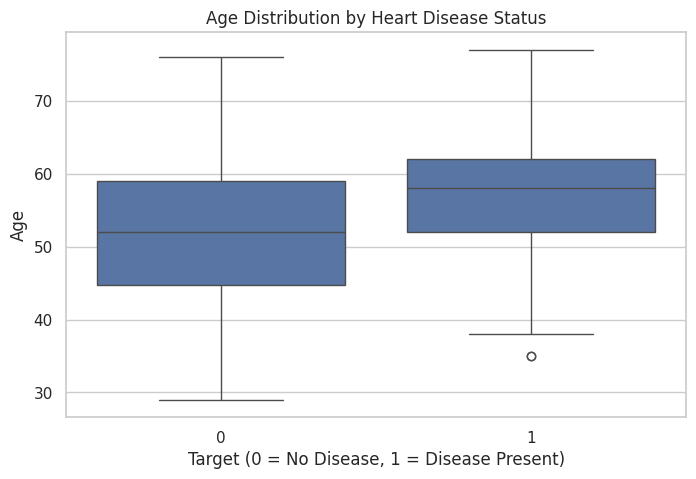

In [7]:
# Step 5: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plotting style
sns.set_theme(style="whitegrid")

# 1. Target Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target_binary"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease Present)")
plt.ylabel("Number of Patients")

plt.show()


# 2. Age Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


# 3. Age vs Heart Disease

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target_binary",
    y="age"
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Target (0 = No Disease, 1 = Disease Present)")
plt.ylabel("Age")

plt.show()

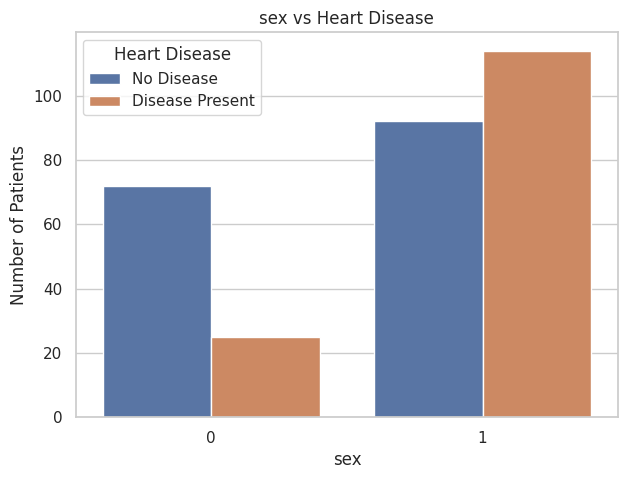

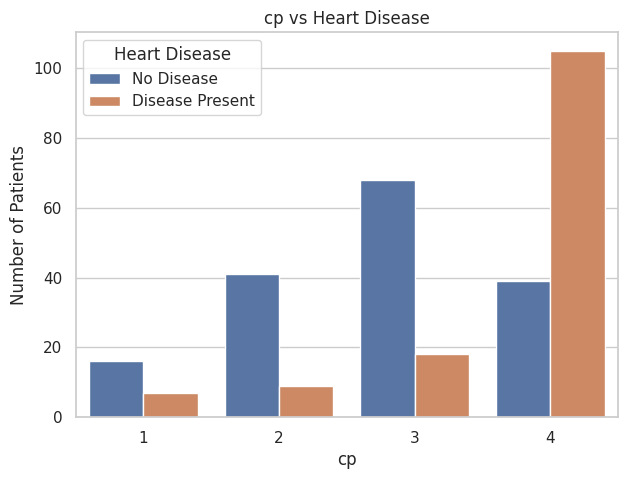

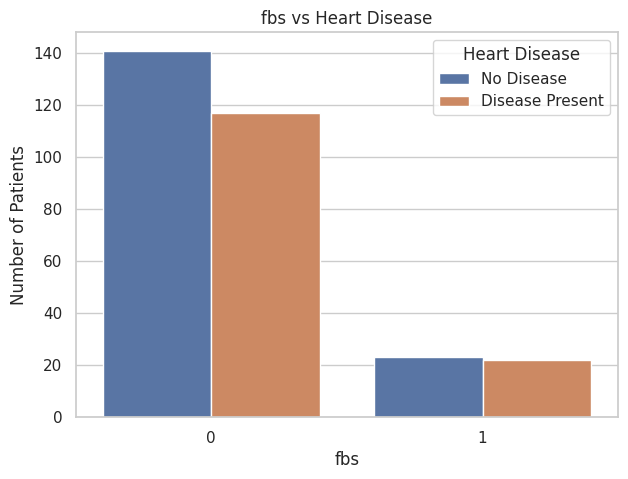

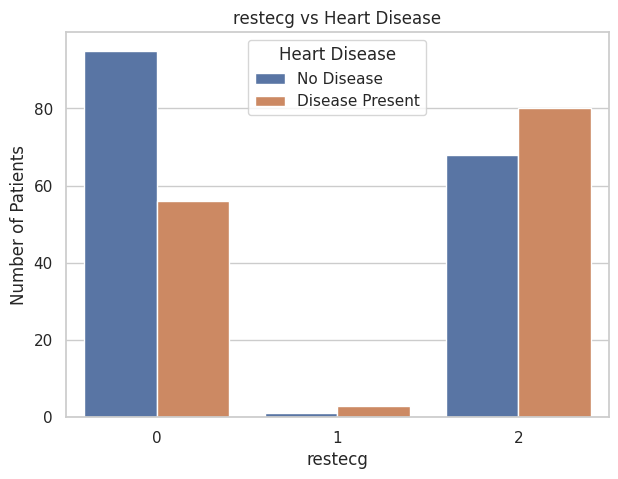

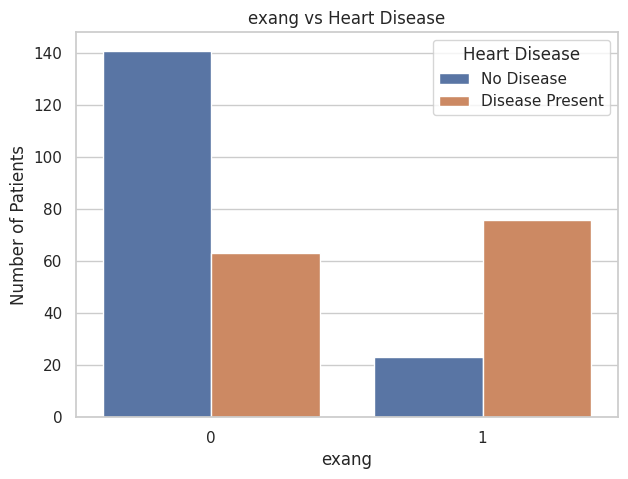

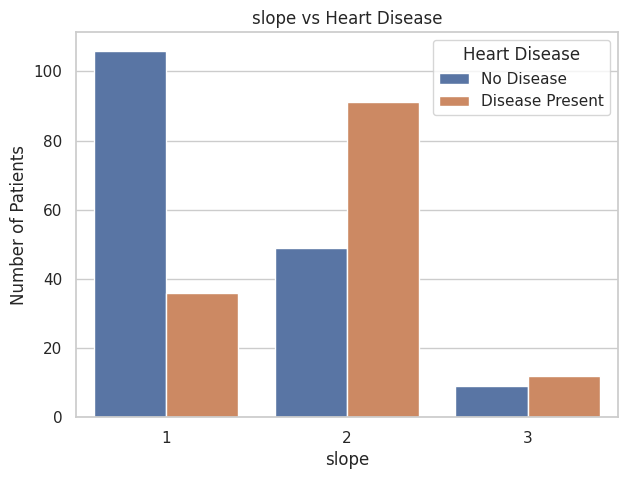

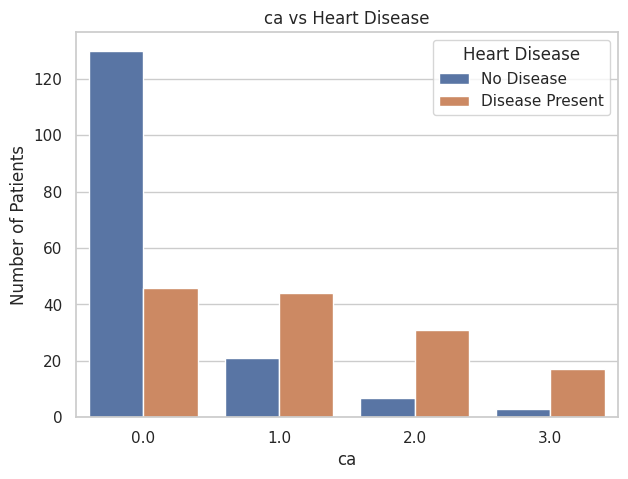

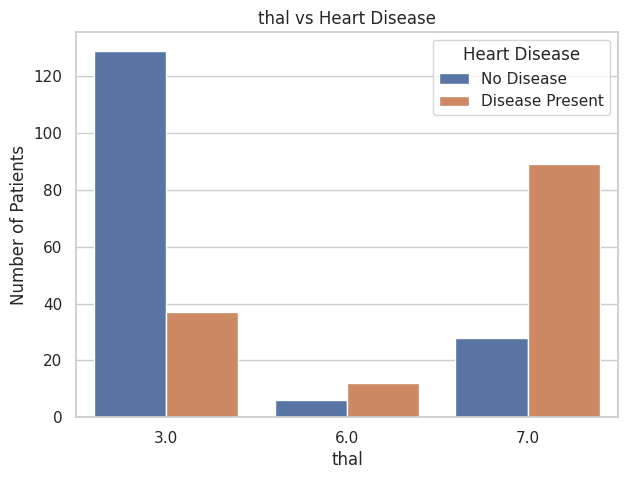

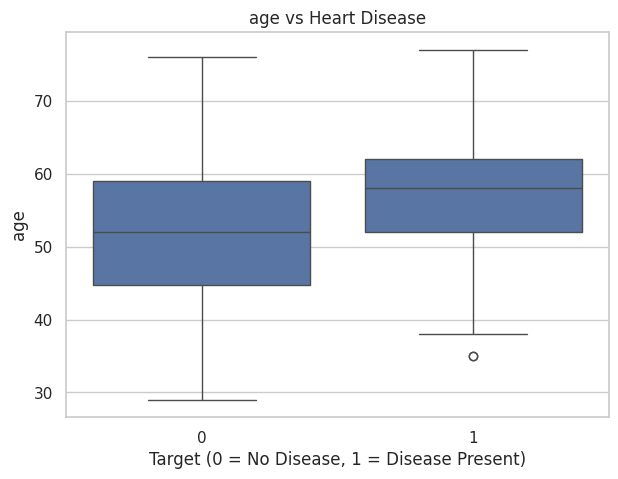

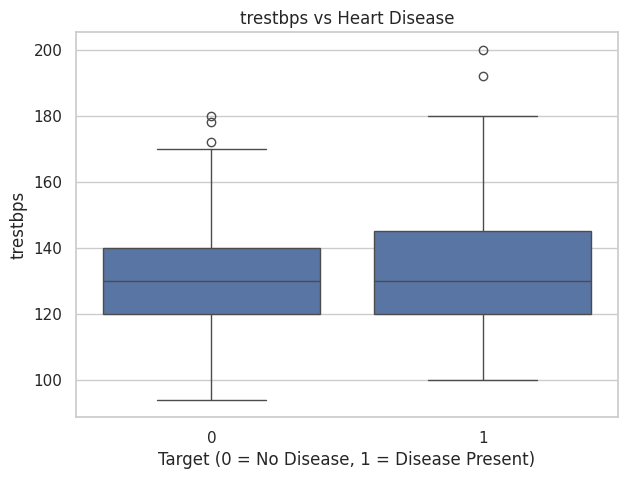

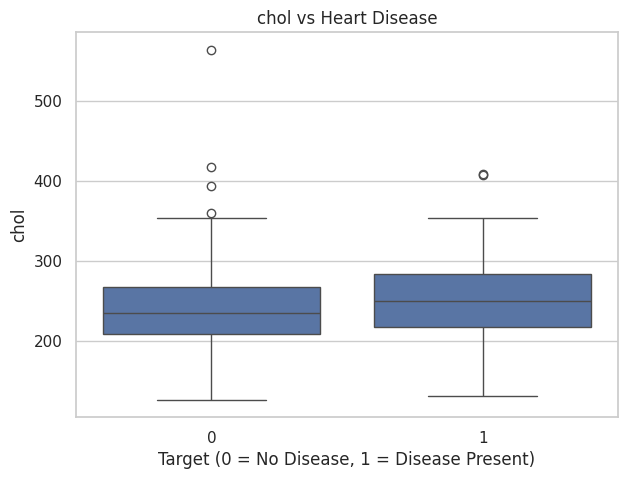

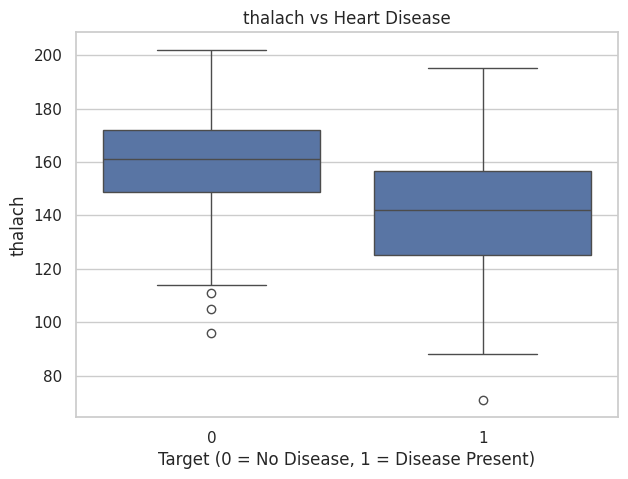

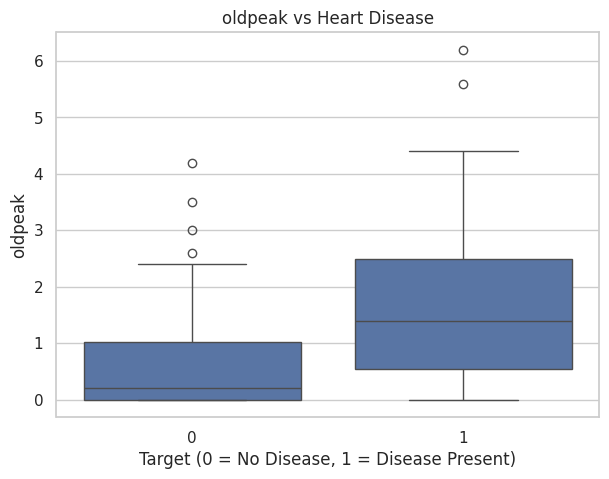

In [8]:
# Step 5B: Feature-wise EDA

# Categorical features
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

# Numerical features
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]


# 1. Categorical Features vs Target

for feature in categorical_features:

    plt.figure(figsize=(7, 5))

    sns.countplot(
        data=df,
        x=feature,
        hue="target_binary"
    )

    plt.title(f"{feature} vs Heart Disease")
    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.legend(
        title="Heart Disease",
        labels=["No Disease", "Disease Present"]
    )

    plt.show()


# 2. Numerical Features vs Target

for feature in numerical_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="target_binary",
        y=feature
    )

    plt.title(f"{feature} vs Heart Disease")
    plt.xlabel("Target (0 = No Disease, 1 = Disease Present)")
    plt.ylabel(feature)

    plt.show()

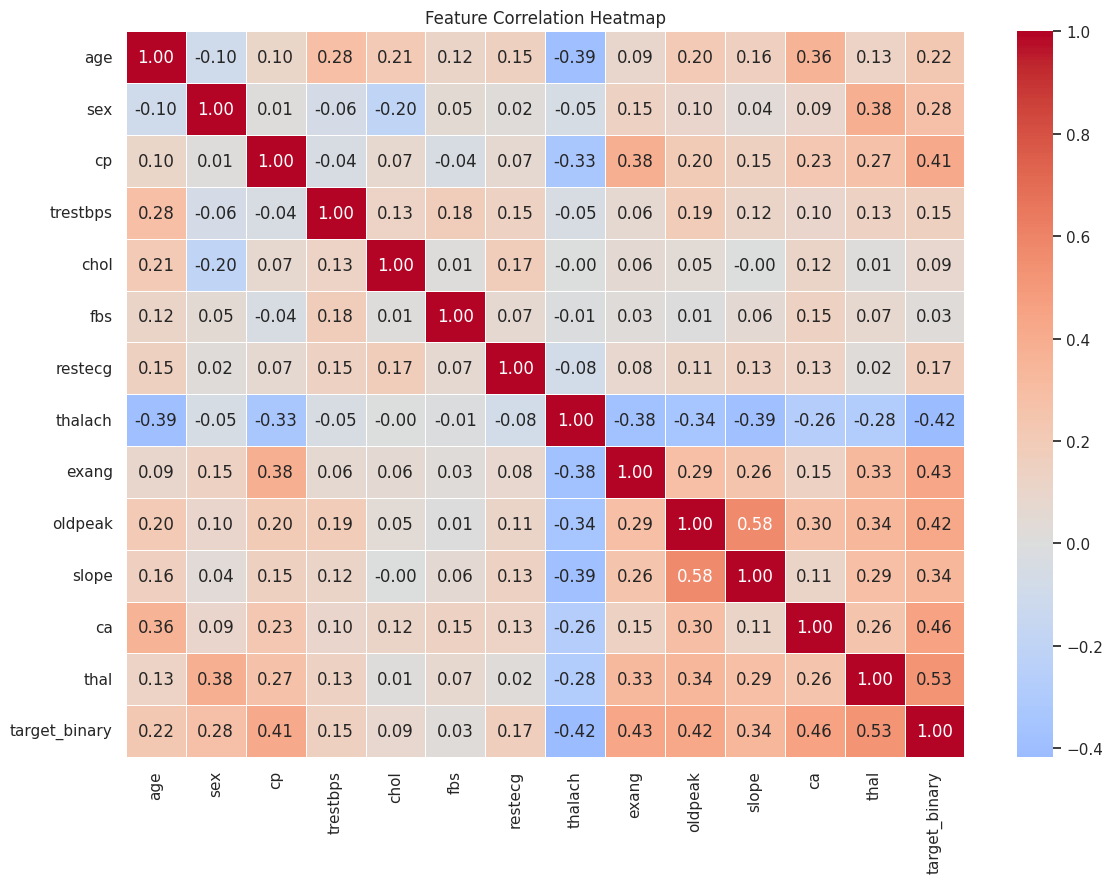

In [9]:
# Step 5C: Correlation Analysis

# Use the cleaned analysis columns for correlation
correlation_data = df.drop(columns=["target"])

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Missing Values:


,Missing Count
ca,4
thal,2


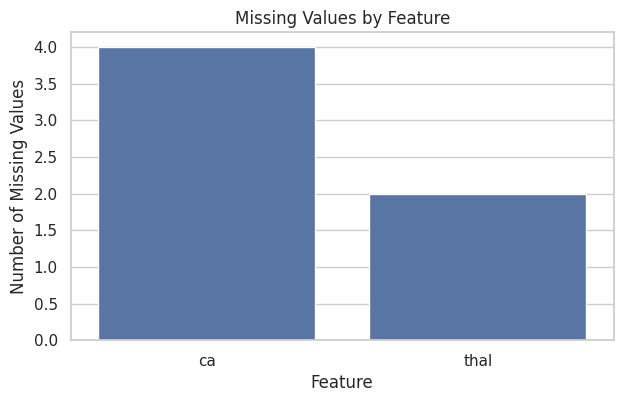

In [10]:
# Step 5D: Missing Value Analysis

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

print("Missing Values:")
display(missing_values.to_frame(name="Missing Count"))

plt.figure(figsize=(7, 4))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")

plt.show()

In [11]:
# Step 6A: Prepare Features and Train/Test Split

from sklearn.model_selection import train_test_split

# Features
X = df.drop(columns=["target", "target_binary"])

# Target
y = df["target_binary"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split completed successfully!")

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Data split completed successfully!

Training set:
X_train: (242, 13)
y_train: (242,)

Testing set:
X_test: (61, 13)
y_test: (61,)

Training target distribution:
target_binary
0    131
1    111
Name: count, dtype: int64

Testing target distribution:
target_binary
0    33
1    28
Name: count, dtype: int64


In [12]:
# Step 6B: Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical features
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Categorical features
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

# Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [13]:
# Step 6C: Apply Preprocessing

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nMissing values after preprocessing:")
print("Training:", X_train_processed.shape[0] - X_train_processed.shape[0])
print("Testing :", X_test_processed.shape[0] - X_test_processed.shape[0])

Preprocessing completed successfully!

Processed training shape: (242, 28)
Processed testing shape: (61, 28)

Missing values after preprocessing:
Training: 0
Testing : 0


In [14]:
# Verify that preprocessing produced no NaN values

import numpy as np

print("NaN values in training data:", np.isnan(X_train_processed).sum())
print("NaN values in testing data :", np.isnan(X_test_processed).sum())

NaN values in training data: 0
NaN values in testing data : 0


In [15]:
# Step 7A: Train Multiple ML Models

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# Store trained pipelines
trained_models = {}

print("Training models...\n")

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name}: Training completed")

print("\nAll models trained successfully!")

Training models...

Logistic Regression: Training completed
Decision Tree: Training completed
Random Forest: Training completed
XGBoost: Training completed
SVM: Training completed

All models trained successfully!


In [16]:
# Step 7B: Generate Predictions

predictions = {}

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    predictions[name] = y_pred

    print(f"{name}: Predictions generated")

print("\nPrediction generation completed!")

Logistic Regression: Predictions generated
Decision Tree: Predictions generated
Random Forest: Predictions generated
XGBoost: Predictions generated
SVM: Predictions generated

Prediction generation completed!


In [17]:
# Step 8A: Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, pipeline in trained_models.items():

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Prediction probabilities
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Create comparison DataFrame
results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("Model Evaluation Completed!\n")

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Model Evaluation Completed!



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
1,SVM,0.8852,0.8387,0.9286,0.8814,0.9643
2,XGBoost,0.9016,0.8438,0.9643,0.9000,0.9448
3,Random Forest,0.8689,0.8125,0.9286,0.8667,0.9443
4,Decision Tree,0.7377,0.7000,0.7500,0.7241,0.7451



Logistic Regression
[[28  5]
 [ 2 26]]


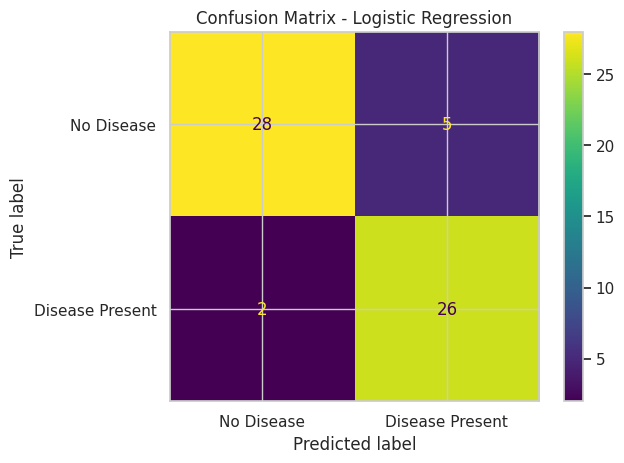


Decision Tree
[[24  9]
 [ 7 21]]


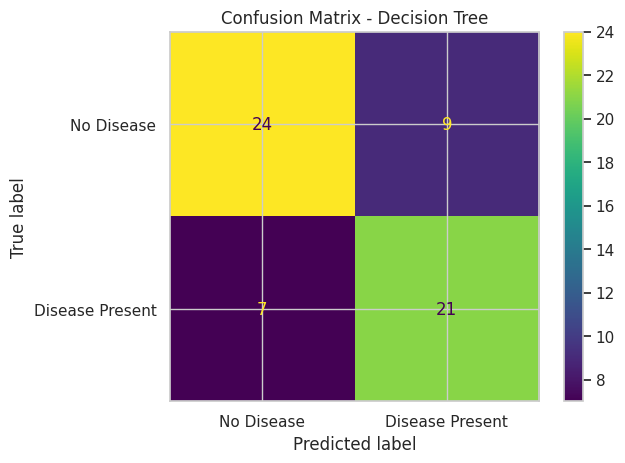


Random Forest
[[27  6]
 [ 2 26]]


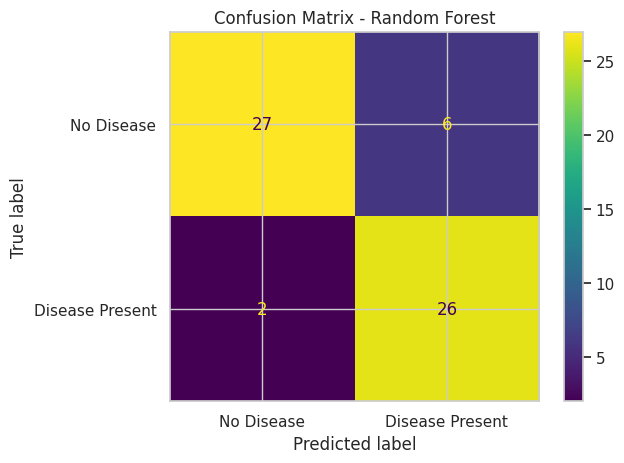


XGBoost
[[28  5]
 [ 1 27]]


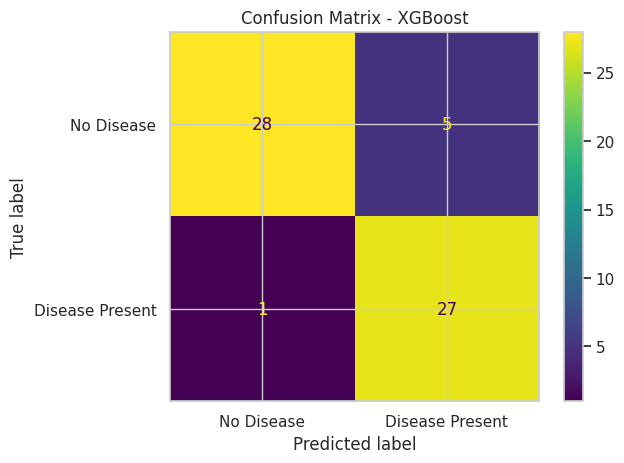


SVM
[[28  5]
 [ 2 26]]


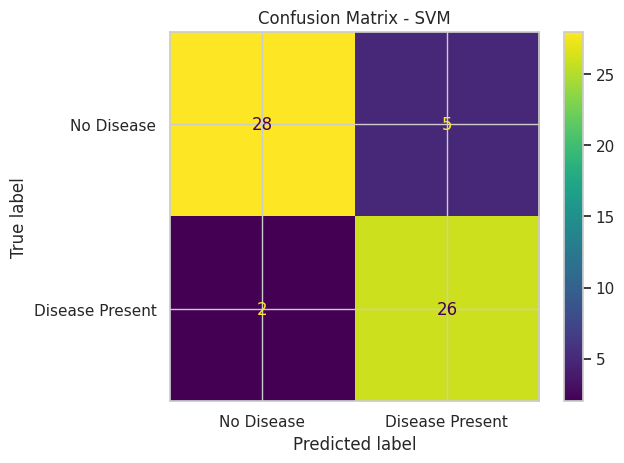

In [18]:
# Step 8B: Confusion Matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease Present"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [19]:
# Step 9A: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Models to tune
tuning_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

# Hyperparameter grids
param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "lbfgs"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
}

# Store tuning results
tuned_models = {}
tuning_results = []

print("Starting hyperparameter tuning...\n")

for name in tuning_models:

    print(f"Tuning {name}...")

    # Create complete pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", tuning_models[name])
        ]
    )

    # Grid search
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    # Fit only on training data
    grid_search.fit(X_train, y_train)

    # Store best model
    tuned_models[name] = grid_search.best_estimator_

    # Store results
    tuning_results.append({
        "Model": name,
        "Best CV ROC-AUC": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

    print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    print("-" * 60)

print("\nHyperparameter tuning completed!")

Starting hyperparameter tuning...

Tuning Logistic Regression...
Best CV ROC-AUC: 0.9025
Best Parameters: {'model__C': 1, 'model__solver': 'liblinear'}
------------------------------------------------------------
Tuning SVM...
Best CV ROC-AUC: 0.9047
Best Parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
------------------------------------------------------------
Tuning Random Forest...
Best CV ROC-AUC: 0.9051
Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}
------------------------------------------------------------
Tuning XGBoost...
Best CV ROC-AUC: 0.8971
Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 300, 'model__subsample': 0.8}
------------------------------------------------------------

Hyperparameter tuning completed!


In [20]:
# Step 9B: Compare Tuned Models

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="Best CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("Tuned Model Comparison:\n")

display(
    tuning_results_df.style.format({
        "Best CV ROC-AUC": "{:.4f}"
    })
)

Tuned Model Comparison:



,Model,Best CV ROC-AUC,Best Parameters
0,Random Forest,0.9051,"{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}"
1,SVM,0.9047,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}"
2,Logistic Regression,0.9025,"{'model__C': 1, 'model__solver': 'liblinear'}"
3,XGBoost,0.8971,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 300, 'model__subsample': 0.8}"


In [21]:
# Step 9C: Final Test Evaluation of Tuned Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_results = []

for name, pipeline in tuned_models.items():

    # Predict on untouched test set
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    final_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Create final comparison table
final_results_df = pd.DataFrame(final_results)

# Sort by ROC-AUC
final_results_df = final_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("Final Test Set Evaluation:\n")

display(
    final_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Final Test Set Evaluation:



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
1,XGBoost,0.8852,0.8621,0.8929,0.8772,0.9535
2,Random Forest,0.8525,0.8065,0.8929,0.8475,0.9481
3,SVM,0.8361,0.8000,0.8571,0.8276,0.9426


In [22]:
# Step 10A: SHAP Setup

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select our final tuned model
final_model = tuned_models["Logistic Regression"]

# Extract fitted preprocessing and model
fitted_preprocessor = final_model.named_steps["preprocessor"]
logistic_model = final_model.named_steps["model"]

# Transform training and test data
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

print("SHAP setup completed!")

print("\nOriginal number of features:", X_train.shape[1])
print("Features after preprocessing:", X_train_transformed.shape[1])

print("\nFirst 10 transformed feature names:")
print(feature_names[:10])

SHAP setup completed!

Original number of features: 13
Features after preprocessing: 28

First 10 transformed feature names:
['num__age' 'num__trestbps' 'num__chol' 'num__thalach' 'num__oldpeak'
 'cat__sex_0.0' 'cat__sex_1.0' 'cat__cp_1.0' 'cat__cp_2.0' 'cat__cp_3.0']


In [23]:
# Step 10B: Create SHAP Explainer

# Create SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(
    logistic_model,
    X_train_transformed,
    feature_names=feature_names
)

# Calculate SHAP values for test data
shap_values = explainer(X_test_transformed)

print("SHAP values calculated successfully!")

print("\nSHAP values shape:", shap_values.values.shape)
print("Test data shape:", X_test_transformed.shape)

SHAP values calculated successfully!

SHAP values shape: (61, 28)
Test data shape: (61, 28)


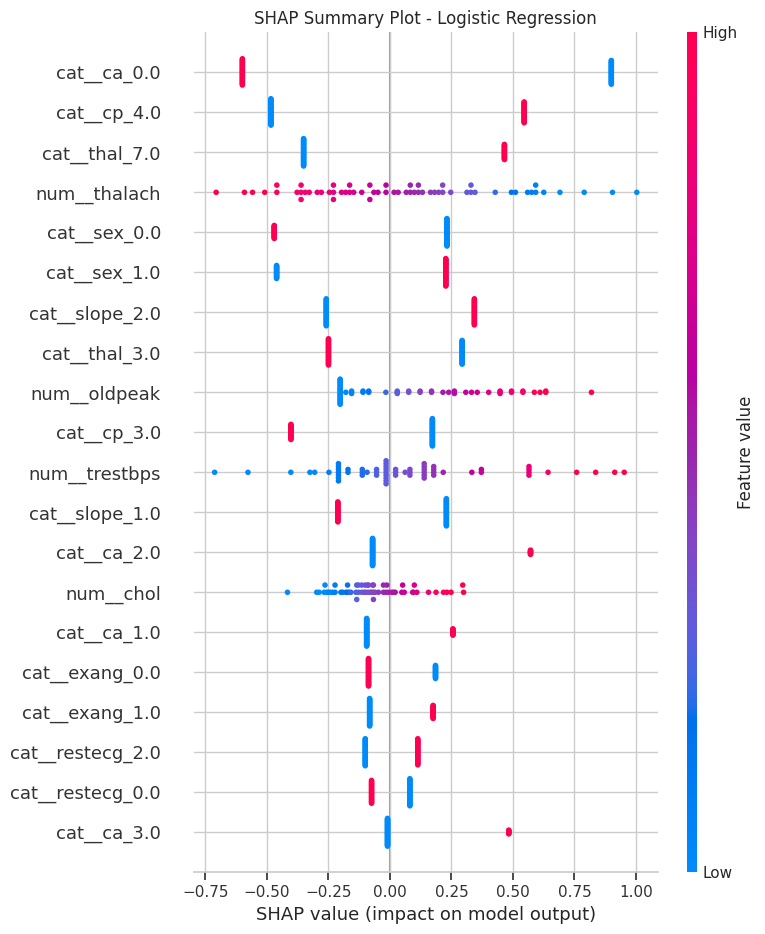

In [24]:
# Step 10C: SHAP Global Feature Importance

# Create a DataFrame for the transformed test data
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# SHAP Summary Plot
plt.figure()

shap.summary_plot(
    shap_values.values,
    X_test_shap,
    show=False
)

plt.title("SHAP Summary Plot - Logistic Regression")
plt.tight_layout()
plt.show()

In [25]:
# Step 10D: Numerical SHAP Feature Importance

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP Value|": np.abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean |SHAP Value|",
    ascending=False
).reset_index(drop=True)

print("Top 15 Most Important Features:\n")

display(
    shap_importance.head(15).style.format({
        "Mean |SHAP Value|": "{:.4f}"
    })
)

Top 15 Most Important Features:



,Feature,Mean |SHAP Value|
0,cat__ca_0.0,0.7425
1,cat__cp_4.0,0.5111
2,cat__thal_7.0,0.3923
3,num__thalach,0.3156
4,cat__sex_0.0,0.3099
5,cat__sex_1.0,0.3036
6,cat__slope_2.0,0.3003
7,cat__thal_3.0,0.2706
8,num__oldpeak,0.2568
9,cat__cp_3.0,0.2555


Individual Patient Explanation

Patient Index: 219
Actual Outcome: No Disease
Predicted Outcome: No Disease
Disease Probability: 20.91%


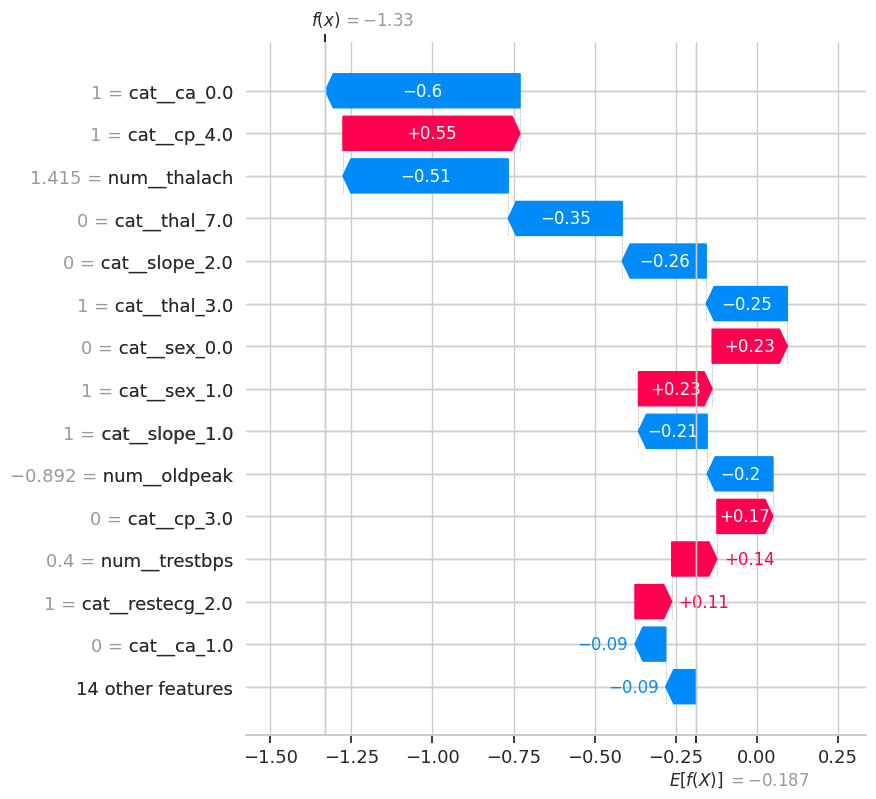

In [26]:
# Step 10E: Individual Patient SHAP Explanation

# Select one patient from the test set
patient_index = X_test.index[0]

# Original patient data
patient_data = X_test.loc[[patient_index]]

# Actual outcome
actual_value = y_test.loc[patient_index]

# Model prediction
predicted_value = final_model.predict(patient_data)[0]

# Prediction probability
prediction_probability = final_model.predict_proba(patient_data)[0, 1]

print("Individual Patient Explanation")
print("=" * 45)

print("\nPatient Index:", patient_index)
print("Actual Outcome:",
      "Disease Present" if actual_value == 1 else "No Disease")

print("Predicted Outcome:",
      "Disease Present" if predicted_value == 1 else "No Disease")

print(f"Disease Probability: {prediction_probability:.2%}")


# Find the SHAP explanation corresponding to this patient
patient_position = list(X_test.index).index(patient_index)

patient_shap_values = shap_values[patient_position]

# Display SHAP waterfall plot
shap.plots.waterfall(
    patient_shap_values,
    max_display=15
)

In [27]:
# Step 11A: LIME Explainer Setup

from lime.lime_tabular import LimeTabularExplainer

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_transformed),
    feature_names=feature_names,
    class_names=["No Disease", "Disease Present"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


In [28]:
# Step 11B: LIME Prediction Function

# LIME works on already-transformed numerical data.
# Therefore, prediction must use the fitted Logistic Regression model.

def lime_predict_proba(transformed_data):
    return logistic_model.predict_proba(transformed_data)


print("LIME prediction function created successfully!")

LIME prediction function created successfully!


In [29]:
# Step 11C: Individual Patient LIME Explanation

# Use the same patient that we explained with SHAP
patient_transformed = X_test_transformed[patient_position]

# Generate LIME explanation
lime_explanation = lime_explainer.explain_instance(
    data_row=np.asarray(patient_transformed),
    predict_fn=lime_predict_proba,
    num_features=15,
    top_labels=2
)

# Print prediction probabilities
lime_probabilities = lime_predict_proba(
    patient_transformed.reshape(1, -1)
)[0]

print("LIME Individual Patient Explanation")
print("=" * 45)

print(f"No Disease Probability: {lime_probabilities[0]:.2%}")
print(f"Disease Probability:    {lime_probabilities[1]:.2%}")

print("\nTop contributing features:")
for feature, weight in lime_explanation.as_list():
    direction = "increases risk" if weight > 0 else "decreases risk"
    print(f"{feature:45s} → {weight:+.4f} ({direction})")

LIME Individual Patient Explanation
No Disease Probability: 79.09%
Disease Probability:    20.91%

Top contributing features:
0.00 < cat__ca_0.0 <= 1.00                    → -0.2818 (decreases risk)
0.00 < cat__cp_4.0 <= 1.00                    → +0.1908 (increases risk)
cat__thal_7.0 <= 0.00                         → -0.1493 (decreases risk)
cat__sex_0.0 <= 0.00                          → +0.1297 (increases risk)
0.00 < cat__sex_1.0 <= 1.00                   → +0.1235 (increases risk)
cat__cp_1.0 <= 0.00                           → +0.1115 (increases risk)
num__thalach > 0.71                           → -0.1113 (decreases risk)
cat__cp_3.0 <= 0.00                           → +0.1088 (increases risk)
cat__ca_2.0 <= 0.00                           → -0.1065 (decreases risk)
cat__slope_2.0 <= 0.00                        → -0.1052 (decreases risk)
0.00 < cat__thal_3.0 <= 1.00                  → -0.0988 (decreases risk)
cat__ca_3.0 <= 0.00                           → -0.0879 (decreases risk

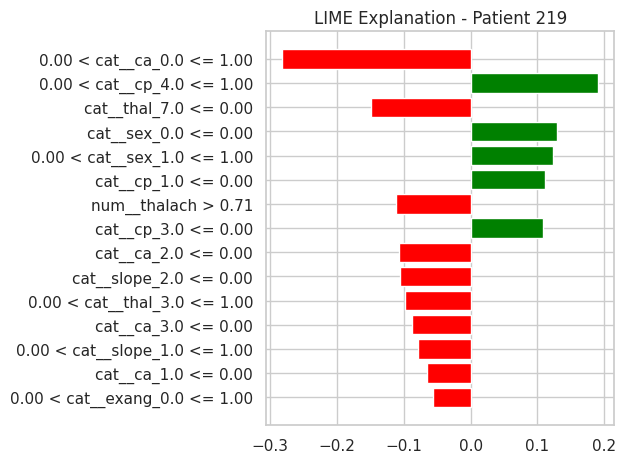

In [30]:
# Step 11D: Display LIME Explanation

fig = lime_explanation.as_pyplot_figure()

plt.title("LIME Explanation - Patient 219")
plt.tight_layout()
plt.show()

In [31]:
# Step 11E: Clean XAI Feature Names

def clean_feature_name(feature):
    """
    Convert transformed feature names into readable names.
    """

    # Numerical features
    if feature.startswith("num__"):
        return feature.replace("num__", "")

    # Categorical features
    if feature.startswith("cat__"):
        feature = feature.replace("cat__", "")

        # Convert one-hot encoded categories
        if "_" in feature:
            original, value = feature.rsplit("_", 1)

            readable_names = {
                "sex": "Sex",
                "cp": "Chest Pain Type",
                "fbs": "Fasting Blood Sugar",
                "restecg": "Resting ECG",
                "exang": "Exercise Angina",
                "slope": "ST Slope",
                "ca": "Major Vessels",
                "thal": "Thalassemia"
            }

            original = readable_names.get(original, original)

            return f"{original} = {value}"

    return feature


# Create clean feature names
clean_feature_names = [
    clean_feature_name(feature)
    for feature in feature_names
]

print("Clean feature names created successfully!\n")

for original, clean in zip(feature_names[:15], clean_feature_names[:15]):
    print(f"{original:30s} → {clean}")

Clean feature names created successfully!

num__age                       → age
num__trestbps                  → trestbps
num__chol                      → chol
num__thalach                   → thalach
num__oldpeak                   → oldpeak
cat__sex_0.0                   → Sex = 0.0
cat__sex_1.0                   → Sex = 1.0
cat__cp_1.0                    → Chest Pain Type = 1.0
cat__cp_2.0                    → Chest Pain Type = 2.0
cat__cp_3.0                    → Chest Pain Type = 3.0
cat__cp_4.0                    → Chest Pain Type = 4.0
cat__fbs_0.0                   → Fasting Blood Sugar = 0.0
cat__fbs_1.0                   → Fasting Blood Sugar = 1.0
cat__restecg_0.0               → Resting ECG = 0.0
cat__restecg_1.0               → Resting ECG = 1.0


In [32]:
# Step 11F: Correct LIME Disease Explanation

# Create LIME explainer with readable feature names
lime_explainer_clean = LimeTabularExplainer(
    training_data=np.asarray(X_train_transformed),
    feature_names=clean_feature_names,
    class_names=["No Disease", "Disease Present"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Explain Disease Present (class 1)
lime_explanation_disease = lime_explainer_clean.explain_instance(
    data_row=np.asarray(patient_transformed),
    predict_fn=lime_predict_proba,
    num_features=15,
    labels=[1]
)

print("LIME Explanation for Disease Present")
print("=" * 50)

for feature, weight in lime_explanation_disease.as_list(label=1):

    direction = (
        "→ increases disease probability"
        if weight > 0
        else "→ decreases disease probability"
    )

    print(f"{feature:45s} {weight:+.4f} {direction}")

LIME Explanation for Disease Present
0.00 < Major Vessels = 0.0 <= 1.00            -0.2818 → decreases disease probability
0.00 < Chest Pain Type = 4.0 <= 1.00          +0.1908 → increases disease probability
Thalassemia = 7.0 <= 0.00                     -0.1493 → decreases disease probability
Sex = 0.0 <= 0.00                             +0.1297 → increases disease probability
0.00 < Sex = 1.0 <= 1.00                      +0.1235 → increases disease probability
Chest Pain Type = 1.0 <= 0.00                 +0.1115 → increases disease probability
thalach > 0.71                                -0.1113 → decreases disease probability
Chest Pain Type = 3.0 <= 0.00                 +0.1088 → increases disease probability
Major Vessels = 2.0 <= 0.00                   -0.1065 → decreases disease probability
ST Slope = 2.0 <= 0.00                        -0.1052 → decreases disease probability
0.00 < Thalassemia = 3.0 <= 1.00              -0.0988 → decreases disease probability
Major Vessels = 3

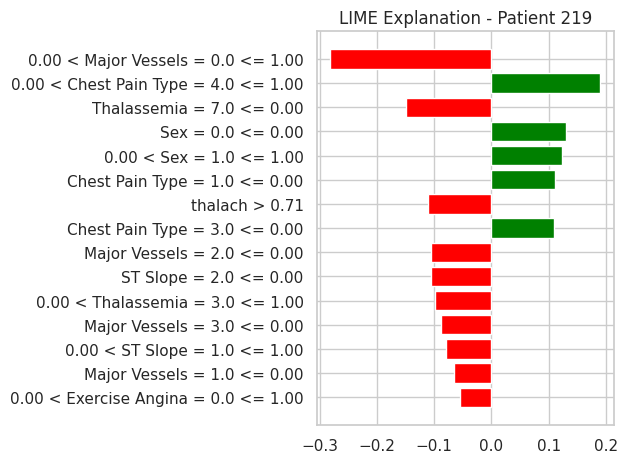

In [33]:
# Step 11G: Clean LIME Visualization

fig = lime_explanation_disease.as_pyplot_figure(label=1)

plt.title("LIME Explanation - Patient 219")
plt.tight_layout()
plt.show()

In [34]:
# Step 11H: SHAP vs LIME Comparison

# SHAP importance for Patient 219
patient_shap_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "SHAP Value": patient_shap_values.values
})

patient_shap_df["Absolute SHAP"] = np.abs(
    patient_shap_df["SHAP Value"]
)

patient_shap_df = patient_shap_df.sort_values(
    by="Absolute SHAP",
    ascending=False
)

# LIME weights for Disease Present
lime_list = lime_explanation_disease.as_list(label=1)

lime_df = pd.DataFrame(
    lime_list,
    columns=["Feature", "LIME Weight"]
)

lime_df["Absolute LIME"] = np.abs(
    lime_df["LIME Weight"]
)

# Display top features
print("Top SHAP Features:")
display(
    patient_shap_df[
        ["Feature", "SHAP Value"]
    ].head(10)
)

print("\nTop LIME Features:")
display(
    lime_df[
        ["Feature", "LIME Weight"]
    ].head(10)
)

Top SHAP Features:


,Feature,SHAP Value
21,Major Vessels = 0.0,-0.599911
10,Chest Pain Type = 4.0,0.545569
3,thalach,-0.509188
27,Thalassemia = 7.0,-0.351033
19,ST Slope = 2.0,-0.258880
25,Thalassemia = 3.0,-0.249915
5,Sex = 0.0,0.231678
6,Sex = 1.0,0.226966
18,ST Slope = 1.0,-0.211761
4,oldpeak,-0.202467



Top LIME Features:


,Feature,LIME Weight
0,0.00 < Major Vessels = 0.0 <= 1.00,-0.281767
1,0.00 < Chest Pain Type = 4.0 <= 1.00,0.190841
2,Thalassemia = 7.0 <= 0.00,-0.149278
3,Sex = 0.0 <= 0.00,0.129654
4,0.00 < Sex = 1.0 <= 1.00,0.123529
5,Chest Pain Type = 1.0 <= 0.00,0.111506
6,thalach > 0.71,-0.111299
7,Chest Pain Type = 3.0 <= 0.00,0.108813
8,Major Vessels = 2.0 <= 0.00,-0.106479
9,ST Slope = 2.0 <= 0.00,-0.105231


In [35]:
# Step 12A: Patient Prediction Function

def predict_heart_disease(patient_data):
    """
    Predict heart disease probability for a new patient.

    Parameters
    ----------
    patient_data : dict
        Patient clinical features.

    Returns
    -------
    prediction : int
        0 = No Disease
        1 = Disease Present

    probability : float
        Model-estimated probability of disease.
    """

    # Convert dictionary to DataFrame
    patient_df = pd.DataFrame([patient_data])

    # Make prediction
    prediction = final_model.predict(patient_df)[0]

    # Disease probability
    probability = final_model.predict_proba(patient_df)[0, 1]

    return prediction, probability


print("Patient prediction function created successfully!")

Patient prediction function created successfully!


In [36]:
# Step 12B: Sample Patient Prediction

sample_patient = {
    "age": 55,
    "sex": 1,
    "cp": 3,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 2,
    "ca": 0,
    "thal": 3
}

prediction, probability = predict_heart_disease(
    sample_patient
)

print("Sample Patient Prediction")
print("=" * 45)

print("Prediction:",
      "Disease Present" if prediction == 1 else "No Disease")

print(f"Disease Probability: {probability:.2%}")
print(f"No Disease Probability: {(1 - probability):.2%}")

Sample Patient Prediction
Prediction: No Disease
Disease Probability: 16.55%
No Disease Probability: 83.45%


In [37]:
# Step 12C: Patient Input Validation

def validate_patient_data(patient_data):

    required_features = [
        "age",
        "sex",
        "cp",
        "trestbps",
        "chol",
        "fbs",
        "restecg",
        "thalach",
        "exang",
        "oldpeak",
        "slope",
        "ca",
        "thal"
    ]

    # Check missing features
    missing_features = [
        feature
        for feature in required_features
        if feature not in patient_data
    ]

    if missing_features:
        raise ValueError(
            f"Missing features: {missing_features}"
        )

    # Basic numeric validation
    if not 1 <= patient_data["age"] <= 120:
        raise ValueError("Age must be between 1 and 120.")

    if patient_data["sex"] not in [0, 1]:
        raise ValueError("Sex must be 0 or 1.")

    if patient_data["cp"] not in [1, 2, 3, 4]:
        raise ValueError("CP must be between 1 and 4.")

    if patient_data["fbs"] not in [0, 1]:
        raise ValueError("FBS must be 0 or 1.")

    if patient_data["restecg"] not in [0, 1, 2]:
        raise ValueError("Resting ECG must be 0, 1, or 2.")

    if patient_data["exang"] not in [0, 1]:
        raise ValueError("Exercise Angina must be 0 or 1.")

    if patient_data["slope"] not in [1, 2, 3]:
        raise ValueError("Slope must be 1, 2, or 3.")

    if patient_data["ca"] not in [0, 1, 2, 3]:
        raise ValueError("CA must be between 0 and 3.")

    if patient_data["thal"] not in [3, 6, 7]:
        raise ValueError("Thal must be 3, 6, or 7.")

    return True


print("Patient validation function created successfully!")

Patient validation function created successfully!


In [38]:
# Step 12D: Complete Prediction System

def run_prediction(patient_data):

    # Validate input
    validate_patient_data(patient_data)

    # Prediction
    prediction, probability = predict_heart_disease(
        patient_data
    )

    result = {
        "Prediction": (
            "Disease Present"
            if prediction == 1
            else "No Disease"
        ),
        "Disease Probability": probability,
        "No Disease Probability": 1 - probability
    }

    return result


# Test complete prediction system
result = run_prediction(sample_patient)

print("Complete Prediction System")
print("=" * 45)

print("Prediction:", result["Prediction"])
print(
    f"Disease Probability: "
    f"{result['Disease Probability']:.2%}"
)
print(
    f"No Disease Probability: "
    f"{result['No Disease Probability']:.2%}"
)

Complete Prediction System
Prediction: No Disease
Disease Probability: 16.55%
No Disease Probability: 83.45%


In [42]:
# Step 12E: SHAP Explanation for New Patient

def explain_new_patient(patient_data, max_features=10):

    # Validate patient input
    validate_patient_data(patient_data)

    # Convert patient data to DataFrame
    patient_df = pd.DataFrame([patient_data])

    # Transform using fitted preprocessing pipeline
    patient_transformed = fitted_preprocessor.transform(
        patient_df
    )

    # Calculate SHAP values
    patient_explanation = explainer(
        patient_transformed
    )

    # Create readable explanation table
    explanation_df = pd.DataFrame({
        "Feature": clean_feature_names,
        "SHAP Value": patient_explanation.values[0]
    })

    explanation_df["Absolute SHAP"] = np.abs(
        explanation_df["SHAP Value"]
    )

    explanation_df = explanation_df.sort_values(
        by="Absolute SHAP",
        ascending=False
    ).reset_index(drop=True)

    # Model prediction
    prediction = final_model.predict(patient_df)[0]

    # Disease probability
    probability = final_model.predict_proba(
        patient_df
    )[0, 1]

    print("New Patient XAI Explanation")
    print("=" * 50)

    print(
        "Prediction:",
        "Disease Present"
        if prediction == 1
        else "No Disease"
    )

    print(f"Disease Probability: {probability:.2%}")
    print(f"No Disease Probability: {(1 - probability):.2%}")

    print("\nTop Contributing Features:")

    display(
        explanation_df[
            ["Feature", "SHAP Value"]
        ].head(max_features)
    )

    return patient_explanation, explanation_df

In [43]:
# Step 12E Test

new_patient_shap, new_patient_explanation = explain_new_patient(
    sample_patient
)

New Patient XAI Explanation
Prediction: No Disease
Disease Probability: 16.55%
No Disease Probability: 83.45%

Top Contributing Features:


,Feature,SHAP Value
0,Major Vessels = 0.0,-0.599911
1,Chest Pain Type = 4.0,-0.483807
2,Chest Pain Type = 3.0,-0.402600
3,Thalassemia = 7.0,-0.351033
4,ST Slope = 2.0,0.343166
5,Thalassemia = 3.0,-0.249915
6,Sex = 0.0,0.231678
7,ST Slope = 1.0,0.229408
8,Sex = 1.0,0.226966
9,Resting ECG = 2.0,-0.100385


In [44]:
# Step 13A: Save Final Model & Preprocessor

import os
import joblib

# Create models directory
os.makedirs("models", exist_ok=True)

# Save complete final pipeline
joblib.dump(
    final_model,
    "models/heart_disease_logistic_pipeline.pkl"
)

# Save preprocessor separately
joblib.dump(
    fitted_preprocessor,
    "models/heart_disease_preprocessor.pkl"
)

# Save model information
model_info = {
    "model_name": "Logistic Regression",
    "dataset": "UCI Heart Disease Dataset",
    "n_original_features": 13,
    "n_processed_features": 28,
    "test_accuracy": 0.8852,
    "test_precision": 0.8387,
    "test_recall": 0.9286,
    "test_f1": 0.8814,
    "test_roc_auc": 0.9665
}

joblib.dump(
    model_info,
    "models/model_info.pkl"
)

print("Model files saved successfully!")

print("\nSaved files:")
for file in os.listdir("models"):
    print("✓", file)

Model files saved successfully!

Saved files:
✓ model_info.pkl
✓ heart_disease_logistic_pipeline.pkl
✓ heart_disease_preprocessor.pkl


In [45]:
# Step 13B: Verify Saved Model

loaded_model = joblib.load(
    "models/heart_disease_logistic_pipeline.pkl"
)

loaded_preprocessor = joblib.load(
    "models/heart_disease_preprocessor.pkl"
)

loaded_model_info = joblib.load(
    "models/model_info.pkl"
)

print("Saved model loaded successfully!")

print("\nModel:", loaded_model_info["model_name"])
print("Dataset:", loaded_model_info["dataset"])
print("Test Accuracy:", loaded_model_info["test_accuracy"])
print("Test Recall:", loaded_model_info["test_recall"])
print("Test ROC-AUC:", loaded_model_info["test_roc_auc"])

Saved model loaded successfully!

Model: Logistic Regression
Dataset: UCI Heart Disease Dataset
Test Accuracy: 0.8852
Test Recall: 0.9286
Test ROC-AUC: 0.9665


In [46]:
# Step 13C: Create Project Folder Structure

import os

folders = [
    "AI_Health_XAI",
    "AI_Health_XAI/models",
    "AI_Health_XAI/app",
    "AI_Health_XAI/notebooks",
    "AI_Health_XAI/assets"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folder structure created successfully!\n")

for root, dirs, files in os.walk("AI_Health_XAI"):
    level = root.replace("AI_Health_XAI", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

Project folder structure created successfully!

AI_Health_XAI/
    models/
    assets/
    app/
    notebooks/


In [47]:
# Copy saved model files into project structure

import shutil

model_files = [
    "heart_disease_logistic_pipeline.pkl",
    "heart_disease_preprocessor.pkl",
    "model_info.pkl"
]

for file in model_files:
    shutil.copy(
        f"models/{file}",
        f"AI_Health_XAI/models/{file}"
    )

print("Model files copied successfully!\n")

print("Project model files:")
for file in os.listdir("AI_Health_XAI/models"):
    print("✓", file)

Model files copied successfully!

Project model files:
✓ model_info.pkl
✓ heart_disease_logistic_pipeline.pkl
✓ heart_disease_preprocessor.pkl


In [48]:
# Step 13D-1: Save XAI Artifacts

import os
import joblib
import numpy as np

# Make sure project directories exist
os.makedirs("AI_Health_XAI/models", exist_ok=True)

# Use a fixed SHAP background dataset
# Maximum 100 samples keeps the Streamlit app lightweight
background_size = min(100, X_train_transformed.shape[0])

shap_background = np.asarray(
    X_train_transformed[:background_size]
)

# Save SHAP background data
joblib.dump(
    shap_background,
    "AI_Health_XAI/models/shap_background.pkl"
)

# Save transformed feature names
joblib.dump(
    feature_names,
    "AI_Health_XAI/models/feature_names.pkl"
)

# Save clean/readable feature names
joblib.dump(
    clean_feature_names,
    "AI_Health_XAI/models/clean_feature_names.pkl"
)

print("XAI artifacts saved successfully!\n")

print("Saved XAI files:")
print("✓ shap_background.pkl")
print("✓ feature_names.pkl")
print("✓ clean_feature_names.pkl")

XAI artifacts saved successfully!

Saved XAI files:
✓ shap_background.pkl
✓ feature_names.pkl
✓ clean_feature_names.pkl


In [49]:
# Step 13D-2: Verify XAI Artifacts

loaded_background = joblib.load(
    "AI_Health_XAI/models/shap_background.pkl"
)

loaded_feature_names = joblib.load(
    "AI_Health_XAI/models/feature_names.pkl"
)

loaded_clean_feature_names = joblib.load(
    "AI_Health_XAI/models/clean_feature_names.pkl"
)

print("XAI artifacts loaded successfully!\n")

print("SHAP background shape:",
      loaded_background.shape)

print("Feature names:",
      len(loaded_feature_names))

print("Clean feature names:",
      len(loaded_clean_feature_names))

print("\nFirst 5 clean feature names:")
print(loaded_clean_feature_names[:5])

XAI artifacts loaded successfully!

SHAP background shape: (100, 28)
Feature names: 28
Clean feature names: 28

First 5 clean feature names:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [50]:
# Step 13E: Create Streamlit Application

import os

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt


# Page Configuration

st.set_page_config(
    page_title="AI Health XAI",
    page_icon="❤️",
    layout="wide"
)


# Load Saved Files

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "heart_disease_logistic_pipeline.pkl"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "models",
    "heart_disease_preprocessor.pkl"
)

BACKGROUND_PATH = os.path.join(
    BASE_DIR,
    "models",
    "shap_background.pkl"
)

FEATURE_NAMES_PATH = os.path.join(
    BASE_DIR,
    "models",
    "clean_feature_names.pkl"
)

MODEL_INFO_PATH = os.path.join(
    BASE_DIR,
    "models",
    "model_info.pkl"
)


@st.cache_resource
def load_model():

    model = joblib.load(MODEL_PATH)
    preprocessor = joblib.load(PREPROCESSOR_PATH)
    background = joblib.load(BACKGROUND_PATH)
    feature_names = joblib.load(FEATURE_NAMES_PATH)
    model_info = joblib.load(MODEL_INFO_PATH)

    return (
        model,
        preprocessor,
        background,
        feature_names,
        model_info
    )


model, preprocessor, background, feature_names, model_info = load_model()


# SHAP Explainer

@st.cache_resource
def create_shap_explainer(_model, _background):

    logistic_model = _model.named_steps["model"]

    explainer = shap.LinearExplainer(
        logistic_model,
        _background
    )

    return explainer


shap_explainer = create_shap_explainer(
    model,
    background
)


# Header

st.title("❤️ AI-Based Early Disease Prediction")
st.subheader("Explainable AI (XAI) for Heart Disease")

st.write(
    """
This application uses a machine learning model to estimate
the probability of heart disease based on patient information.

The application also provides an explanation of the model's
prediction using SHAP (SHapley Additive exPlanations).
"""
)

st.warning(
    "This application is for educational and research purposes only. "
    "It is not a medical diagnosis or a substitute for professional "
    "medical advice."
)


# Sidebar - Model Information

with st.sidebar:

    st.header("Model Information")

    st.write(
        f"**Model:** {model_info['model_name']}"
    )

    st.write(
        f"**Dataset:** {model_info['dataset']}"
    )

    st.write(
        f"**Test Accuracy:** "
        f"{model_info['test_accuracy']:.2%}"
    )

    st.write(
        f"**Test Recall:** "
        f"{model_info['test_recall']:.2%}"
    )

    st.write(
        f"**Test ROC-AUC:** "
        f"{model_info['test_roc_auc']:.4f}"
    )


# Patient Information

st.header("Patient Information")

col1, col2, col3 = st.columns(3)


with col1:

    age = st.number_input(
        "Age",
        min_value=1,
        max_value=120,
        value=55
    )

    sex = st.selectbox(
        "Sex",
        options=[0, 1],
        format_func=lambda x:
            "Female (0)" if x == 0 else "Male (1)"
    )

    cp = st.selectbox(
        "Chest Pain Type",
        options=[1, 2, 3, 4]
    )

    trestbps = st.number_input(
        "Resting Blood Pressure",
        min_value=50,
        max_value=250,
        value=130
    )

    chol = st.number_input(
        "Cholesterol",
        min_value=50,
        max_value=700,
        value=250
    )


with col2:

    fbs = st.selectbox(
        "Fasting Blood Sugar",
        options=[0, 1],
        format_func=lambda x:
            "No (0)" if x == 0 else "Yes (1)"
    )

    restecg = st.selectbox(
        "Resting ECG",
        options=[0, 1, 2]
    )

    thalach = st.number_input(
        "Maximum Heart Rate",
        min_value=40,
        max_value=250,
        value=150
    )

    exang = st.selectbox(
        "Exercise Induced Angina",
        options=[0, 1],
        format_func=lambda x:
            "No (0)" if x == 0 else "Yes (1)"
    )

    oldpeak = st.number_input(
        "ST Depression (Oldpeak)",
        min_value=0.0,
        max_value=10.0,
        value=1.0,
        step=0.1
    )


with col3:

    slope = st.selectbox(
        "ST Slope",
        options=[1, 2, 3]
    )

    ca = st.selectbox(
        "Major Vessels (CA)",
        options=[0, 1, 2, 3]
    )

    thal = st.selectbox(
        "Thalassemia",
        options=[3, 6, 7]
    )


# Prediction Button

st.divider()

predict_button = st.button(
    "🔍 Predict Heart Disease",
    type="primary",
    use_container_width=True
)


if predict_button:

    # Create patient dataframe
    patient_data = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])

    # Prediction

    prediction = model.predict(patient_data)[0]

    probabilities = model.predict_proba(
        patient_data
    )[0]

    no_disease_probability = probabilities[0]
    disease_probability = probabilities[1]


    # Display Result

    st.header("Prediction Result")

    result_col1, result_col2 = st.columns(2)

    with result_col1:

        if prediction == 1:

            st.error(
                "⚠️ Model Prediction: Disease Present"
            )

        else:

            st.success(
                "✅ Model Prediction: No Disease"
            )

    with result_col2:

        st.metric(
            "Disease Probability",
            f"{disease_probability:.2%}"
        )


    # Probability chart
    probability_df = pd.DataFrame(
        {
            "Outcome": [
                "No Disease",
                "Disease Present"
            ],
            "Probability": [
                no_disease_probability,
                disease_probability
            ]
        }
    )

    st.bar_chart(
        probability_df.set_index("Outcome")
    )


    # SHAP Explanation

    st.header("🔎 Explainable AI")

    st.write(
        """
The chart below shows which patient features influenced
the model's prediction. Positive SHAP values push the
prediction toward Disease Present, while negative values
push it toward No Disease.
"""
    )

    # Transform patient
    patient_transformed = preprocessor.transform(
        patient_data
    )

    # Calculate SHAP values
    shap_explanation = shap_explainer(
        patient_transformed
    )

    shap_values = shap_explanation.values[0]

    explanation_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP Value": shap_values
    })

    explanation_df["Absolute SHAP"] = np.abs(
        explanation_df["SHAP Value"]
    )

    explanation_df = explanation_df.sort_values(
        by="Absolute SHAP",
        ascending=False
    ).head(10)


    # SHAP Bar Chart

    chart_df = explanation_df[
        ["Feature", "SHAP Value"]
    ].set_index("Feature")

    st.bar_chart(chart_df)


    # SHAP Explanation Table

    st.subheader("Top Contributing Features")

    display_df = explanation_df[
        ["Feature", "SHAP Value"]
    ].copy()

    display_df["Direction"] = np.where(
        display_df["SHAP Value"] > 0,
        "Increases Disease Probability",
        "Decreases Disease Probability"
    )

    st.dataframe(
        display_df,
        use_container_width=True,
        hide_index=True
    )


# Footer

st.divider()

st.caption(
    "AI Health XAI | Educational Machine Learning Project"
)
'''

# Create app directory
os.makedirs(
    "AI_Health_XAI/app",
    exist_ok=True
)

# Write app.py
with open(
    "AI_Health_XAI/app/app.py",
    "w",
    encoding="utf-8"
) as f:

    f.write(app_code)

print("Streamlit app created successfully!")
print()
print("File:")
print("✓ AI_Health_XAI/app/app.py")

Streamlit app created successfully!

File:
✓ AI_Health_XAI/app/app.py


In [51]:
# Step 13F: Create requirements.txt

requirements = """streamlit
pandas
numpy
scikit-learn
xgboost
shap
matplotlib
joblib
"""

with open(
    "AI_Health_XAI/requirements.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print("requirements.txt created successfully!\n")

print("Required libraries:")
print(requirements)

requirements.txt created successfully!

Required libraries:
streamlit
pandas
numpy
scikit-learn
xgboost
shap
matplotlib
joblib



In [52]:
# Step 13F-2: Verify Streamlit App File

app_path = "AI_Health_XAI/app/app.py"

if os.path.exists(app_path):

    file_size = os.path.getsize(app_path)

    print("Streamlit app file verified successfully!")
    print(f"File size: {file_size:,} bytes")

else:

    print("ERROR: app.py was not found!")

Streamlit app file verified successfully!
File size: 7,520 bytes


In [53]:
# Step 13G-1: Install Streamlit

!pip install -q streamlit

print("Streamlit installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 62.6 MB/s eta 0:00:00
Streamlit installed successfully!


In [54]:
# Step 13G-2: Launch Streamlit App

import subprocess
import time

app_path = "/content/AI_Health_XAI/app/app.py"

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        app_path,
        "--server.port=8501",
        "--server.address=0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Streamlit server started!")
print("Checking server status...")

if process.poll() is None:
    print("✓ Streamlit is running on port 8501")
else:
    print("✗ Streamlit stopped. Check the output above.")

Streamlit server started!
Checking server status...
✓ Streamlit is running on port 8501


In [56]:
# 13G-3: Streamlit App Verification

import os
import py_compile

app_path = "/content/AI_Health_XAI/app/app.py"
models_path = "/content/AI_Health_XAI/models"

# 1. Check app.py syntax
try:
    py_compile.compile(app_path, doraise=True)
    print("✅ app.py syntax check: PASSED")
except Exception as e:
    print("❌ app.py syntax check: FAILED")
    print(e)

# 2. Check required files
required_files = [
    "app.py",
    "../models/heart_disease_logistic_pipeline.pkl",
    "../models/heart_disease_preprocessor.pkl",
    "../models/model_info.pkl",
    "../models/shap_background.pkl",
    "../models/feature_names.pkl",
    "../models/clean_feature_names.pkl"
]

print("\n📁 Required Files:")

for file in required_files:
    full_path = os.path.join("/content/AI_Health_XAI/app", file)
    if os.path.exists(full_path):
        print(f"✅ {file}")
    else:
        print(f"❌ {file}")

print("\n🔍 App verification completed.")

✅ app.py syntax check: PASSED

📁 Required Files:
✅ app.py
✅ ../models/heart_disease_logistic_pipeline.pkl
✅ ../models/heart_disease_preprocessor.pkl
✅ ../models/model_info.pkl
✅ ../models/shap_background.pkl
✅ ../models/feature_names.pkl
✅ ../models/clean_feature_names.pkl

🔍 App verification completed.


In [57]:
# 13G-4: Saved Model Load + Prediction Test

import joblib
import pandas as pd
import os

# Paths
base_path = "/content/AI_Health_XAI"

model_path = os.path.join(
    base_path, "models", "heart_disease_logistic_pipeline.pkl"
)

# Load the complete pipeline
loaded_model = joblib.load(model_path)

print("✅ Model loaded successfully!")
print("Model type:", type(loaded_model))

# Sample patient
sample_patient = {
    "age": 55,
    "sex": 1,
    "cp": 3,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 2,
    "ca": 0,
    "thal": 3
}

# Convert to DataFrame
patient_df = pd.DataFrame([sample_patient])

# Prediction
prediction = loaded_model.predict(patient_df)[0]
probabilities = loaded_model.predict_proba(patient_df)[0]

disease_probability = probabilities[1] * 100
no_disease_probability = probabilities[0] * 100

print("\n--- Prediction Test ---")

if prediction == 1:
    print("Prediction: ❤️ Heart Disease Present")
else:
    print("Prediction: 💚 No Heart Disease")

print(f"Disease Probability: {disease_probability:.2f}%")
print(f"No Disease Probability: {no_disease_probability:.2f}%")

print("\n✅ Saved model prediction test completed.")

✅ Model loaded successfully!
Model type: <class 'sklearn.pipeline.Pipeline'>

--- Prediction Test ---
Prediction: 💚 No Heart Disease
Disease Probability: 16.55%
No Disease Probability: 83.45%

✅ Saved model prediction test completed.


In [58]:
# 13G-5: SHAP Explanation Test

import joblib
import numpy as np

# Load required XAI artifacts
preprocessor = joblib.load(
    "/content/AI_Health_XAI/models/heart_disease_preprocessor.pkl"
)

shap_background = joblib.load(
    "/content/AI_Health_XAI/models/shap_background.pkl"
)

clean_feature_names = joblib.load(
    "/content/AI_Health_XAI/models/clean_feature_names.pkl"
)

# Get Logistic Regression model from pipeline
logistic_model = loaded_model.named_steps["model"]

# Transform patient data
patient_transformed = preprocessor.transform(patient_df)

# Create SHAP explainer
import shap

explainer = shap.LinearExplainer(
    logistic_model,
    shap_background
)

# Calculate SHAP values
shap_values = explainer(patient_transformed)

# Get values for this patient
patient_shap_values = shap_values.values[0]

# Get top 10 features by absolute SHAP value
top_indices = np.argsort(np.abs(patient_shap_values))[::-1][:10]

print("✅ SHAP explainer created successfully!")

print("\n--- Top 10 SHAP Contributions ---")

for rank, idx in enumerate(top_indices, start=1):
    feature = clean_feature_names[idx]
    value = patient_shap_values[idx]

    if value > 0:
        direction = "Increases Disease Probability"
    else:
        direction = "Decreases Disease Probability"

    print(
        f"{rank}. {feature}: "
        f"{value:.4f} → {direction}"
    )

print("\n✅ SHAP explanation test completed.")

✅ SHAP explainer created successfully!

--- Top 10 SHAP Contributions ---
1. Major Vessels = 0.0: -0.5399 → Decreases Disease Probability
2. Chest Pain Type = 4.0: -0.4838 → Decreases Disease Probability
3. Chest Pain Type = 3.0: -0.4084 → Decreases Disease Probability
4. Thalassemia = 7.0: -0.3429 → Decreases Disease Probability
5. ST Slope = 2.0: 0.3131 → Increases Disease Probability
6. Sex = 0.0: 0.2527 → Increases Disease Probability
7. Sex = 1.0: 0.2476 → Increases Disease Probability
8. Thalassemia = 3.0: -0.2445 → Decreases Disease Probability
9. ST Slope = 1.0: 0.2073 → Increases Disease Probability
10. Resting ECG = 2.0: -0.1004 → Decreases Disease Probability

✅ SHAP explanation test completed.


In [59]:
# 13G-6: Streamlit Runtime Check

import subprocess
import time
import requests

app_path = "/content/AI_Health_XAI/app/app.py"

# Start Streamlit server
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        app_path,
        "--server.port=8501",
        "--server.address=0.0.0.0",
        "--server.headless=true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

# Give Streamlit some time to start
time.sleep(8)

# Check whether the server is responding
try:
    response = requests.get("http://127.0.0.1:8501", timeout=10)

    if response.status_code == 200:
        print("✅ Streamlit server started successfully!")
        print("✅ App is responding on port 8501.")
        print("Status code:", response.status_code)
    else:
        print("⚠️ Streamlit responded with status code:", response.status_code)

except Exception as e:
    print("❌ Streamlit runtime check failed.")
    print(e)

print("\n🔍 Streamlit runtime check completed.")

✅ Streamlit server started successfully!
✅ App is responding on port 8501.
Status code: 200

🔍 Streamlit runtime check completed.


In [60]:
# 13G-7: Finalize requirements.txt

requirements = """streamlit
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
xgboost==3.0.4
shap==0.52.0
matplotlib
joblib
"""

requirements_path = "/content/AI_Health_XAI/requirements.txt"

with open(requirements_path, "w") as f:
    f.write(requirements)

print("✅ requirements.txt updated successfully!")
print("\n--- requirements.txt ---")
print(requirements)

✅ requirements.txt updated successfully!

--- requirements.txt ---
streamlit
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
xgboost==3.0.4
shap==0.52.0
matplotlib
joblib



In [61]:
# 13G-8: Final Project Structure Check

import os

project_path = "/content/AI_Health_XAI"

for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}📁 {os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    📄 {file}")

print("\n✅ Project structure check completed.")

📁 AI_Health_XAI/
    📄 requirements.txt
    📁 models/
        📄 shap_background.pkl
        📄 model_info.pkl
        📄 feature_names.pkl
        📄 clean_feature_names.pkl
        📄 heart_disease_logistic_pipeline.pkl
        📄 heart_disease_preprocessor.pkl
    📁 assets/
    📁 app/
        📄 app.py
        📁 __pycache__/
            📄 app.cpython-313.pyc
    📁 notebooks/

✅ Project structure check completed.


In [62]:
# 13G-9: Project Cleanup + .gitignore

import os
import shutil

project_path = "/content/AI_Health_XAI"

# 1. Remove __pycache__ folders
removed = []

for root, dirs, files in os.walk(project_path):
    if "__pycache__" in dirs:
        cache_path = os.path.join(root, "__pycache__")
        shutil.rmtree(cache_path)
        removed.append(cache_path)

# 2. Create .gitignore
gitignore_content = """# Python
__pycache__/
*.py[cod]
*$py.class

# Jupyter
.ipynb_checkpoints/

# Virtual environments
venv/
env/
.venv/

# OS files
.DS_Store
Thumbs.db

# IDE
.vscode/

# Temporary files
*.tmp
*.log
"""

gitignore_path = os.path.join(project_path, ".gitignore")

with open(gitignore_path, "w") as f:
    f.write(gitignore_content)

print("✅ __pycache__ cleanup completed.")

if removed:
    for path in removed:
        print("🗑️ Removed:", path)
else:
    print("ℹ️ No __pycache__ folder found.")

print("\n✅ .gitignore created successfully!")
print("\n--- .gitignore ---")
print(gitignore_content)

✅ __pycache__ cleanup completed.
🗑️ Removed: /content/AI_Health_XAI/app/__pycache__

✅ .gitignore created successfully!

--- .gitignore ---
# Python
__pycache__/
*.py[cod]
*$py.class

# Jupyter
.ipynb_checkpoints/

# Virtual environments
venv/
env/
.venv/

# OS files
.DS_Store
Thumbs.db

# IDE
.vscode/

# Temporary files
*.tmp
*.log



In [67]:
# 13G-10: Notebook Finalization Preparation

import os

project_path = "/content/AI_Health_XAI"
notebook_path = os.path.join(project_path, "notebooks")

# Create notebooks folder if it doesn't exist
os.makedirs(notebook_path, exist_ok=True)

print("✅ Project folder:", project_path)
print("✅ Notebook folder:", notebook_path)

print("\n📌 Required notebook filename:")
print("AI_Based_Early_Disease_Prediction_XAI.ipynb")

print("\n➡️ Now download the current Colab notebook:")
print("   File → Download → Download .ipynb")

print("\n📂 After downloading, upload it into:")
print(notebook_path)

print("\n✅ 13G-10 preparation completed.")

✅ Project folder: /content/AI_Health_XAI
✅ Notebook folder: /content/AI_Health_XAI/notebooks

📌 Required notebook filename:
AI_Based_Early_Disease_Prediction_XAI.ipynb

➡️ Now download the current Colab notebook:
   File → Download → Download .ipynb

📂 After downloading, upload it into:
/content/AI_Health_XAI/notebooks

✅ 13G-10 preparation completed.


In [71]:
# 13G-11: Create README.md

import os

project_path = "/content/AI_Health_XAI"
readme_path = os.path.join(project_path, "README.md")

lines = [
    "# AI-Based Early Disease Prediction with Explainable AI (XAI)",
    "",
    "## Project Overview",
    "",
    "This project presents an AI-based heart disease prediction system using Machine Learning and Explainable AI (XAI). The system predicts whether heart disease is present and provides probability-based results along with model explanations.",
    "",
    "> **Disclaimer:** This project is developed for educational and research purposes only. It is not a medical diagnostic system and should not be used as a substitute for professional medical advice.",
    "",
    "## Problem Statement",
    "",
    "Heart disease is a major health concern. Machine Learning can help identify patterns associated with heart disease, but model predictions should also be understandable. This project combines Machine Learning with Explainable AI to make predictions more interpretable.",
    "",
    "## Objectives",
    "",
    "- Predict heart disease presence.",
    "- Compare multiple Machine Learning algorithms.",
    "- Perform hyperparameter tuning.",
    "- Select the best-performing model.",
    "- Explain predictions using SHAP and LIME.",
    "- Build an interactive Streamlit application.",
    "",
    "## Dataset",
    "",
    "The project uses the UCI Heart Disease Dataset.",
    "",
    "- Total records: 303",
    "- Input features: 13",
    "- Problem type: Binary classification",
    "",
    "### Target Classes",
    "",
    "| Value | Meaning |",
    "|---|---|",
    "| 0 | No Heart Disease |",
    "| 1 | Heart Disease Present |",
    "",
    "### Input Features",
    "",
    "| Feature | Description |",
    "|---|---|",
    "| age | Age of patient |",
    "| sex | Sex |",
    "| cp | Chest pain type |",
    "| trestbps | Resting blood pressure |",
    "| chol | Serum cholesterol |",
    "| fbs | Fasting blood sugar |",
    "| restecg | Resting ECG results |",
    "| thalach | Maximum heart rate achieved |",
    "| exang | Exercise-induced angina |",
    "| oldpeak | ST depression |",
    "| slope | ST segment slope |",
    "| ca | Number of major vessels |",
    "| thal | Thalassemia |",
    "",
    "## Data Preprocessing",
    "",
    "- Missing-value imputation",
    "- Numerical feature scaling",
    "- Categorical feature encoding",
    "- One-hot encoding",
    "- Scikit-learn Pipeline",
    "- ColumnTransformer",
    "",
    "Original features: 13",
    "",
    "Transformed features: 28",
    "",
    "## Machine Learning Models",
    "",
    "The following models were trained and compared:",
    "",
    "1. Logistic Regression",
    "2. Decision Tree",
    "3. Random Forest",
    "4. XGBoost",
    "5. Support Vector Machine (SVM)",
    "",
    "## Model Evaluation",
    "",
    "Evaluation metrics:",
    "",
    "- Accuracy",
    "- Precision",
    "- Recall",
    "- F1-Score",
    "- ROC-AUC",
    "",
    "### Final Tuned Model Results",
    "",
    "| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |",
    "|---|---:|---:|---:|---:|---:|",
    "| Logistic Regression | 88.52% | 83.87% | 92.86% | 88.14% | **96.65%** |",
    "| XGBoost | 88.52% | 86.21% | 89.29% | 87.72% | 95.35% |",
    "| Random Forest | 85.25% | 80.65% | 89.29% | 84.75% | 94.81% |",
    "| SVM | 83.61% | 80.00% | 85.71% | 82.76% | 94.26% |",
    "",
    "## Final Model",
    "",
    "The final selected model is **Tuned Logistic Regression**.",
    "",
    "Test ROC-AUC: **0.9665**",
    "",
    "Test Recall: **92.86%**",
    "",
    "The model was selected based on its strong ROC-AUC, high recall, and suitability for explainable predictions.",
    "",
    "## Explainable AI",
    "",
    "### SHAP",
    "",
    "SHAP (SHapley Additive exPlanations) is used to understand how individual features influence model predictions.",
    "",
    "The application displays the top contributing features and indicates whether each feature increases or decreases the estimated disease probability.",
    "",
    "### LIME",
    "",
    "LIME (Local Interpretable Model-agnostic Explanations) was also explored to understand individual predictions.",
    "",
    "## Streamlit Application",
    "",
    "An interactive Streamlit application allows users to enter patient information and receive:",
    "",
    "- Heart disease prediction",
    "- Disease probability",
    "- No-disease probability",
    "- SHAP-based explanation",
    "- Top contributing features",
    "",
    "### Application Flow",
    "",
    "Patient Input -> Data Validation -> Preprocessing -> Logistic Regression -> Prediction + Probability -> SHAP Explanation",
    "",
    "## Project Structure",
    "",
    "AI_Health_XAI/",
    "",
    "    app/",
    "        app.py",
    "",
    "    models/",
    "        heart_disease_logistic_pipeline.pkl",
    "        heart_disease_preprocessor.pkl",
    "        model_info.pkl",
    "        shap_background.pkl",
    "        feature_names.pkl",
    "        clean_feature_names.pkl",
    "",
    "    notebooks/",
    "        AI_Based_Early_Disease_Prediction_XAI.ipynb",
    "",
    "    assets/",
    "",
    "    .gitignore",
    "    requirements.txt",
    "    README.md",
    "",
    "## Installation",
    "",
    "Clone the repository and install the dependencies:",
    "",
    "    pip install -r requirements.txt",
    "",
    "## Run the Application",
    "",
    "From the project root directory:",
    "",
    "    streamlit run app/app.py",
    "",
    "## Example Prediction",
    "",
    "Sample patient result:",
    "",
    "Prediction: No Heart Disease",
    "",
    "Disease Probability: 16.55%",
    "",
    "No Disease Probability: 83.45%",
    "",
    "## Technologies Used",
    "",
    "- Python",
    "- Pandas",
    "- NumPy",
    "- Scikit-learn",
    "- XGBoost",
    "- SHAP",
    "- LIME",
    "- Matplotlib",
    "- Joblib",
    "- Streamlit",
    "- Google Colab",
    "",
    "## Future Improvements",
    "",
    "- Add additional disease prediction modules",
    "- Use larger and more diverse datasets",
    "- Improve probability calibration",
    "- Add advanced risk visualization",
    "- Add additional XAI techniques",
    "- Improve user interface",
    "",
    "## Project Purpose",
    "",
    "This project demonstrates the practical application of Machine Learning and Explainable AI to a healthcare-related classification problem.",
    "",
    "## Medical Disclaimer",
    "",
    "This application is intended strictly for educational and research purposes.",
    "",
    "It does not provide medical diagnosis, treatment recommendations, or professional medical advice.",
    "",
    "Users should consult qualified healthcare professionals for medical decisions."
]

readme_content = "\n".join(lines)

with open(readme_path, "w", encoding="utf-8") as file:
    file.write(readme_content)

print("✅ README.md created successfully!")
print("📄 Location:", readme_path)
print("📏 File size:", os.path.getsize(readme_path), "bytes")

✅ README.md created successfully!
📄 Location: /content/AI_Health_XAI/README.md
📏 File size: 5210 bytes


In [72]:
# 13G-12: Assets + Final Project Cleanup

import os

project_path = "/content/AI_Health_XAI"
assets_path = os.path.join(project_path, "assets")

# 1. Make sure assets folder exists
os.makedirs(assets_path, exist_ok=True)

print("✅ Assets folder ready:")
print(assets_path)

# 2. Check important project files
important_files = [
    "README.md",
    ".gitignore",
    "requirements.txt",
    "app/app.py",
    "models/heart_disease_logistic_pipeline.pkl",
    "models/heart_disease_preprocessor.pkl",
    "models/model_info.pkl",
    "models/shap_background.pkl",
    "models/feature_names.pkl",
    "models/clean_feature_names.pkl"
]

print("\n📋 Important files verification:\n")

all_present = True

for relative_path in important_files:
    full_path = os.path.join(project_path, relative_path)

    if os.path.isfile(full_path):
        size = os.path.getsize(full_path)
        print(f"✅ {relative_path}  ({size:,} bytes)")
    else:
        print(f"❌ MISSING: {relative_path}")
        all_present = False

# 3. Check for unwanted files/folders
print("\n🧹 Checking for unwanted files:\n")

unwanted_found = []

for root, dirs, files in os.walk(project_path):
    for directory in dirs:
        if directory == "__pycache__":
            unwanted_found.append(os.path.join(root, directory))

    for file in files:
        if file.endswith(".pyc"):
            unwanted_found.append(os.path.join(root, file))

if unwanted_found:
    for item in unwanted_found:
        print("⚠️ Unwanted:", item)
else:
    print("✅ No __pycache__ or .pyc files found.")

# 4. Final status
print("\n----------------------------------------")

if all_present and not unwanted_found:
    print("✅ 13G-12 FINAL CLEANUP: PASSED")
    print("🚀 Project is ready for backup.")
else:
    print("⚠️ 13G-12 needs attention before backup.")

✅ Assets folder ready:
/content/AI_Health_XAI/assets

📋 Important files verification:

✅ README.md  (5,210 bytes)
✅ .gitignore  (195 bytes)
✅ requirements.txt  (103 bytes)
✅ app/app.py  (7,520 bytes)
✅ models/heart_disease_logistic_pipeline.pkl  (4,950 bytes)
✅ models/heart_disease_preprocessor.pkl  (4,054 bytes)
✅ models/model_info.pkl  (255 bytes)
✅ models/shap_background.pkl  (22,625 bytes)
✅ models/feature_names.pkl  (801 bytes)
✅ models/clean_feature_names.pkl  (543 bytes)

🧹 Checking for unwanted files:

✅ No __pycache__ or .pyc files found.

----------------------------------------
✅ 13G-12 FINAL CLEANUP: PASSED
🚀 Project is ready for backup.


In [76]:
# 13G-13: Final Project ZIP Backup

import os
import shutil

project_path = "/content/AI_Health_XAI"
notebook_dir = os.path.join(project_path, "notebooks")
zip_base = "/content/AI_Health_XAI_FINAL_BACKUP"
zip_path = zip_base + ".zip"

# 1. Check notebook

notebooks = [
    file for file in os.listdir(notebook_dir)
    if file.endswith(".ipynb")
]

print("🔍 Checking final project before backup...\n")

if not notebooks:
    print("❌ Notebook not found!")
    print("\nPlease upload:")
    print("AI_Based_Early_Disease_Prediction_XAI.ipynb")
    print("\nLocation:")
    print(notebook_dir)

else:
    print("✅ Notebook found:")
    for notebook in notebooks:
        print("   📓", notebook)

    # 2. Remove old ZIP

    if os.path.exists(zip_path):
        os.remove(zip_path)
        print("\n🗑️ Old backup removed.")

    # 3. Create fresh ZIP

    new_zip = shutil.make_archive(
        zip_base,
        "zip",
        root_dir="/content",
        base_dir="AI_Health_XAI"
    )

    # 4. Verify ZIP

    if os.path.exists(new_zip):
        size_mb = os.path.getsize(new_zip) / (1024 * 1024)

        print("\n" + "=" * 45)
        print("✅ FINAL BACKUP CREATED SUCCESSFULLY")
        print("=" * 45)

        print("📦 File:", new_zip)
        print(f"📏 Size: {size_mb:.2f} MB")

        print("\n📁 Backup contains:")
        print("   ✅ Application")
        print("   ✅ Models")
        print("   ✅ XAI artifacts")
        print("   ✅ Notebook")
        print("   ✅ README")
        print("   ✅ requirements.txt")
        print("   ✅ .gitignore")

        print("\n🚀 Project is ready for GitHub.")
    else:
        print("❌ Backup creation failed.")

🔍 Checking final project before backup...

❌ Notebook not found!

Please upload:
AI_Based_Early_Disease_Prediction_XAI.ipynb

Location:
/content/AI_Health_XAI/notebooks
